#  IBM HR Attrition — Exploratory Data Analysis
### Python version of our SQL analysis
**Libraries used:** Pandas · Matplotlib · Seaborn


             

---


In [ ]:
#Importing the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Chart style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

print(" Libraries loaded successfully!")


 Libraries loaded successfully!


In [ ]:
###Load Data

df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Attrition ko binary mein convert karo (Yes=1, No=0)
# Calculations mein kaam aayega aage
df["Attrition_Flag"] = df["Attrition"].map({"Yes": 1, "No": 0})

print(f" Data loaded!")
print(f"   Rows (Employees) : {df.shape[0]}")
print(f"   Columns          : {df.shape[1]}")
df.head()


 Data loaded!
   Rows (Employees) : 1470
   Columns          : 36


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0


##  Query 1 — Total Employee Count
```sql
SELECT COUNT(*) FROM employee_attrition;
```


In [ ]:
total = df.shape[0]   # same as len(df)
print(f"Total Employees: {total}")


Total Employees: 1470


## Query 2 — Attrition Count (Yes / No)
```sql
SELECT Attrition, COUNT(*) AS total
FROM employee_attrition
GROUP BY Attrition;
```


In [ ]:
attrition_count = (
    df.groupby("Attrition")       # GROUP BY Attrition
      .size()                     # COUNT(*)
      .reset_index(name="Total")
)
attrition_count


,Attrition,Total
0,No,1233
1,Yes,237


##  Query 3 — Department × Attrition Breakdown
```sql
SELECT Department, Attrition, COUNT(*) AS total
FROM employee_attrition
GROUP BY Department, Attrition
ORDER BY Department;
```


In [ ]:
dept_attrition = (
    df.groupby(["Department", "Attrition"])
      .size()
      .reset_index(name="Total")
      .sort_values("Department")   # ORDER BY Department
)
dept_attrition


,Department,Attrition,Total
0,Human Resources,No,51
1,Human Resources,Yes,12
2,Research & Development,No,828
3,Research & Development,Yes,133
4,Sales,No,354
5,Sales,Yes,92


##  Query 4 — Attrition Rate by Department (%)
```sql
SELECT Department,
    COUNT(*) AS Total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_company,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS attrition_rate
FROM employee_attrition
GROUP BY Department
ORDER BY attrition_rate DESC;
```


In [ ]:
dept_rate = (
    df.groupby("Department")
      .agg(
          Total_Employees = ("Attrition", "count"),      # COUNT(*)
          Left_Company    = ("Attrition_Flag", "sum")    # SUM(CASE WHEN Yes THEN 1)
      )
      .reset_index()
)
dept_rate["Attrition_Rate_%"] = (
    dept_rate["Left_Company"] / dept_rate["Total_Employees"] * 100
).round(1)

dept_rate = dept_rate.sort_values("Attrition_Rate_%", ascending=False)
dept_rate


,Department,Total_Employees,Left_Company,Attrition_Rate_%
2,Sales,446,92,20.6
0,Human Resources,63,12,19.0
1,Research & Development,961,133,13.8


###  Chart — Department Attrition Rate

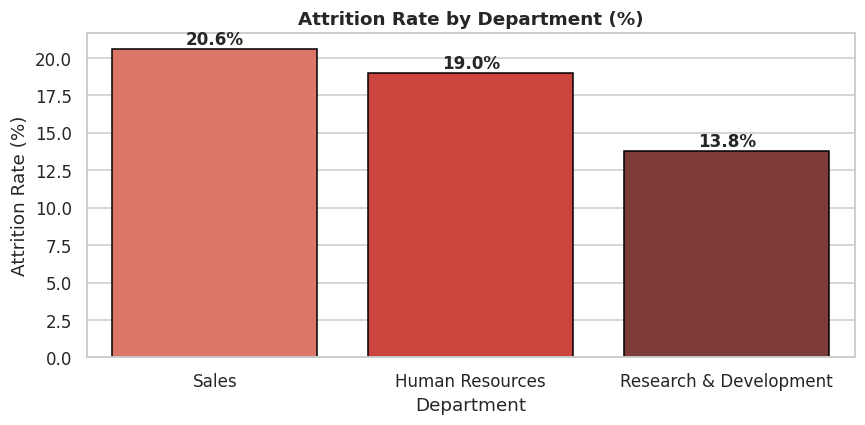

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=dept_rate, x="Department", y="Attrition_Rate_%",
            palette="Reds_d", edgecolor="black")
plt.title("Attrition Rate by Department (%)", fontweight="bold")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")
for i, row in dept_rate.reset_index(drop=True).iterrows():
    plt.text(i, row["Attrition_Rate_%"] + 0.3,
             f"{row['Attrition_Rate_%']}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


##  Query 5 — Average Salary by Attrition Status
```sql
SELECT Attrition, ROUND(AVG(MonthlyIncome), 0) AS avg_salary
FROM employee_attrition
GROUP BY Attrition;
```


In [ ]:
avg_salary = (
    df.groupby("Attrition")["MonthlyIncome"]
      .mean()
      .round(0)
      .reset_index()
)
avg_salary.columns = ["Attrition", "Avg_Monthly_Income"]

diff = (avg_salary.loc[avg_salary["Attrition"]=="No",  "Avg_Monthly_Income"].values[0] -
        avg_salary.loc[avg_salary["Attrition"]=="Yes", "Avg_Monthly_Income"].values[0])

print(f" Insight: Employees who LEFT earned ~${diff:,.0f} LESS on average")
avg_salary


 Insight: Employees who LEFT earned ~$2,046 LESS on average


,Attrition,Avg_Monthly_Income
0,No,6833.0
1,Yes,4787.0


### Chart — Average Salary Comparison

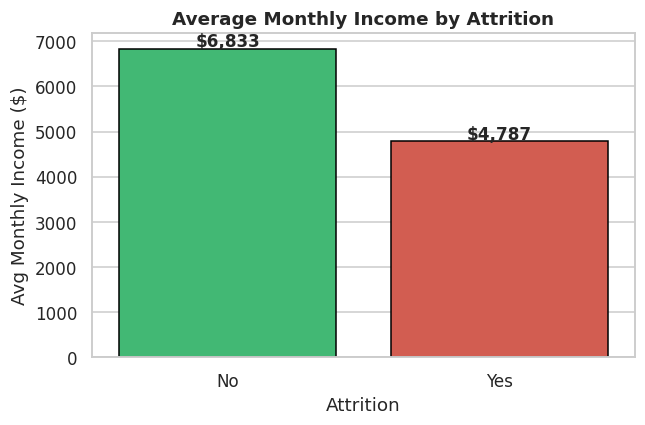

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=avg_salary, x="Attrition", y="Avg_Monthly_Income",
            palette={"No": "#2ecc71", "Yes": "#e74c3c"}, edgecolor="black")
plt.title("Average Monthly Income by Attrition", fontweight="bold")
plt.ylabel("Avg Monthly Income ($)")
for i, row in avg_salary.reset_index(drop=True).iterrows():
    plt.text(i, row["Avg_Monthly_Income"] + 50,
             f"${row['Avg_Monthly_Income']:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


##  Query 6 — Overtime vs Attrition
```sql
SELECT OverTime, COUNT(*) AS total,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_company,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS attrition_rate
FROM employee_attrition
GROUP BY OverTime;
```


In [ ]:
overtime = (
    df.groupby("OverTime")
      .agg(
          Total        = ("Attrition", "count"),
          Left_Company = ("Attrition_Flag", "sum")
      )
      .reset_index()
)
overtime["Attrition_Rate_%"] = (overtime["Left_Company"] / overtime["Total"] * 100).round(1)

ot_yes = overtime.loc[overtime["OverTime"]=="Yes", "Attrition_Rate_%"].values[0]
ot_no  = overtime.loc[overtime["OverTime"]=="No",  "Attrition_Rate_%"].values[0]
print(f"💡 OT employees are {ot_yes/ot_no:.1f}x more likely to leave!")
overtime


💡 OT employees are 2.9x more likely to leave!


,OverTime,Total,Left_Company,Attrition_Rate_%
0,No,1054,110,10.4
1,Yes,416,127,30.5


### Chart — Overtime Impact on Attrition

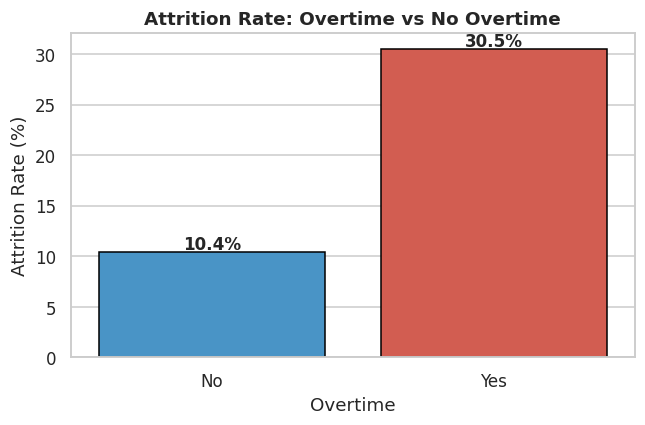

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=overtime, x="OverTime", y="Attrition_Rate_%",
            palette={"No": "#3498db", "Yes": "#e74c3c"}, edgecolor="black")
plt.title("Attrition Rate: Overtime vs No Overtime", fontweight="bold")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Overtime")
for i, row in overtime.reset_index(drop=True).iterrows():
    plt.text(i, row["Attrition_Rate_%"] + 0.3,
             f"{row['Attrition_Rate_%']}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


##  Query 7 — Income Statistics (Min / Max / Avg)
```sql
SELECT MIN(MonthlyIncome), MAX(MonthlyIncome),
       ROUND(AVG(MonthlyIncome), 0) AS avg_income
FROM employee_attrition;
```


In [ ]:
income_stats = df["MonthlyIncome"].agg(["min", "max", "mean"]).round(0)
print(f"Minimum Income : ${income_stats['min']:,.0f}")
print(f"Maximum Income : ${income_stats['max']:,.0f}")
print(f"Average Income : ${income_stats['mean']:,.0f}")


Minimum Income : $1,009
Maximum Income : $19,999
Average Income : $6,503


## Query 8 — Attrition by Salary Band
```sql
SELECT
    CASE
        WHEN MonthlyIncome < 3000 THEN 'Low'
        WHEN MonthlyIncome BETWEEN 3000 AND 7000 THEN 'Mid'
        ELSE 'High'
    END AS salary_band,
    COUNT(*) AS total,
    ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),1) AS attrition_rate
FROM employee_attrition
GROUP BY salary_band
ORDER BY attrition_rate DESC;
```


In [ ]:
# pd.cut() = SQL ka CASE WHEN for number ranges
df["Salary_Band"] = pd.cut(
    df["MonthlyIncome"],
    bins   = [0, 2999, 7000, float("inf")],
    labels = ["Low (<3k)", "Mid (3k-7k)", "High (>7k)"]
)

salary_band = (
    df.groupby("Salary_Band", observed=True)
      .agg(
          Total        = ("Attrition", "count"),
          Left_Company = ("Attrition_Flag", "sum")
      )
      .reset_index()
)
salary_band["Attrition_Rate_%"] = (
    salary_band["Left_Company"] / salary_band["Total"] * 100
).round(1)
salary_band = salary_band.sort_values("Attrition_Rate_%", ascending=False)
print(" Low salary band has highest attrition — compensation is a key driver!")
salary_band


 Low salary band has highest attrition — compensation is a key driver!


,Salary_Band,Total,Left_Company,Attrition_Rate_%
0,Low (<3k),395,113,28.6
1,Mid (3k-7k),640,77,12.0
2,High (>7k),435,47,10.8


###  Chart — Salary Band Attrition

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=salary_band, x="Salary_Band", y="Attrition_Rate_%",
            palette="OrRd", edgecolor="black")
plt.title("Attrition Rate by Salary Band", fontweight="bold")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Salary Band")
for i, row in salary_band.reset_index(drop=True).iterrows():
    plt.text(i, row["Attrition_Rate_%"] + 0.3,
             f"{row['Attrition_Rate_%']}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


##  Query 9 — CTE: High Risk Employees
```sql
WITH high_risk AS (
  SELECT * FROM employee_attrition
  WHERE OverTime = 'Yes'
    AND JobSatisfaction <= 2
    AND MonthlyIncome < 5000
)
SELECT Department, COUNT(*) AS high_risk_count
FROM high_risk
GROUP BY Department
ORDER BY high_risk_count DESC;
```



In [ ]:
# high_risk variable = SQL ka WITH high_risk AS (...)
high_risk = df[
    (df["OverTime"] == "Yes") &
    (df["JobSatisfaction"] <= 2) &
    (df["MonthlyIncome"] < 5000)
]

high_risk_dept = (
    high_risk.groupby("Department")
             .size()
             .reset_index(name="High_Risk_Count")
             .sort_values("High_Risk_Count", ascending=False)
)
print(f" Total High-Risk Employees: {len(high_risk)} — Immediate HR attention needed!")
high_risk_dept


 Total High-Risk Employees: 79 — Immediate HR attention needed!


,Department,High_Risk_Count
1,Research & Development,60
2,Sales,14
0,Human Resources,5


**bold text**##  Query 10 — Tenure Analysis (Years at Company)
```sql
SELECT YearsAtCompany, COUNT(*) AS total,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS left_company,
    ROUND(SUM(...) * 100.0 / COUNT(*), 1) AS attrition_rate
FROM employee_attrition
GROUP BY YearsAtCompany
ORDER BY YearsAtCompany;
```


In [ ]:
tenure = (
    df.groupby("YearsAtCompany")
      .agg(
          Total        = ("Attrition", "count"),
          Left_Company = ("Attrition_Flag", "sum")
      )
      .reset_index()
      .sort_values("YearsAtCompany")
)
tenure["Attrition_Rate_%"] = (tenure["Left_Company"] / tenure["Total"] * 100).round(1)

danger_zone = tenure[tenure["Attrition_Rate_%"] > 25]["YearsAtCompany"].tolist()
print(f" Danger Zone (>25% attrition) at Years: {danger_zone}")
tenure


 Danger Zone (>25% attrition) at Years: [0, 1, 23, 31, 32, 40]


,YearsAtCompany,Total,Left_Company,Attrition_Rate_%
0,0,44,16,36.4
1,1,171,59,34.5
2,2,127,27,21.3
3,3,128,20,15.6
4,4,110,19,17.3
5,5,196,21,10.7
6,6,76,9,11.8
7,7,90,11,12.2
8,8,80,9,11.2
9,9,82,8,9.8


Chart — Attrition by Tenure

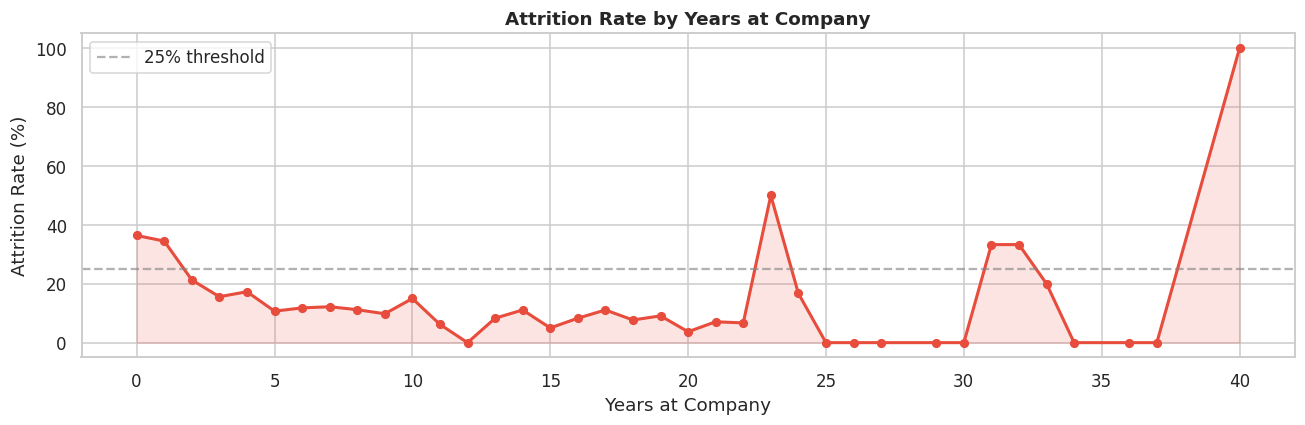

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(tenure["YearsAtCompany"], tenure["Attrition_Rate_%"],
         marker="o", color="#e74c3c", linewidth=2, markersize=5)
plt.axhline(y=25, color="gray", linestyle="--", alpha=0.6, label="25% threshold")
plt.fill_between(tenure["YearsAtCompany"], tenure["Attrition_Rate_%"],
                 alpha=0.15, color="#e74c3c")
plt.title("Attrition Rate by Years at Company", fontweight="bold")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.legend()
plt.tight_layout()
plt.show()


##  Query 11 — Subquery: Departments Above Average Attrition
```sql
SELECT Department,
    ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS attrition_rate
FROM employee_attrition
GROUP BY Department
HAVING attrition_rate > (
    SELECT AVG(CASE WHEN Attrition = 'Yes' THEN 1.0 ELSE 0 END) * 100
    FROM employee_attrition
);
```
>


In [ ]:
# Subquery — overall average nikalna
overall_avg = df["Attrition_Flag"].mean() * 100
print(f"Overall Avg Attrition (subquery result): {overall_avg:.1f}%")

# Main query — department rates
dept_rates = (
    df.groupby("Department")["Attrition_Flag"]
      .mean() * 100
).round(1).reset_index()
dept_rates.columns = ["Department", "Attrition_Rate_%"]

# HAVING = filter after groupby
above_avg = dept_rates[dept_rates["Attrition_Rate_%"] > overall_avg]
above_avg = above_avg.sort_values("Attrition_Rate_%", ascending=False)

print(f"\nDepartments ABOVE average:")
above_avg


Overall Avg Attrition (subquery result): 16.1%

Departments ABOVE average:


,Department,Attrition_Rate_%
2,Sales,20.6
0,Human Resources,19.0


##  Final Summary — Key Business Insights

In [ ]:
overall_rate = df["Attrition_Flag"].mean() * 100
ot_rate      = df[df["OverTime"]=="Yes"]["Attrition_Flag"].mean() * 100
low_sal_rate = df[df["Salary_Band"]=="Low (<3k)"]["Attrition_Flag"].mean() * 100
top_dept     = dept_rate.iloc[0]["Department"]
top_dept_rt  = dept_rate.iloc[0]["Attrition_Rate_%"]

print("=" * 55)
print("  KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"  1. Overall Attrition Rate    : {overall_rate:.1f}%")
print(f"  2. OT Employees Attrition    : {ot_rate:.1f}%   <- HIGH RISK")
print(f"  3. Low Salary Band Attrition : {low_sal_rate:.1f}%   <- COMPENSATION ISSUE")
print(f"  4. Highest Attrition Dept    : {top_dept} ({top_dept_rt}%)")
print(f"  5. High-Risk Employees       : {len(high_risk)} people (OT + Low Satisfaction + Low Pay)")
print(  "  6. Danger Zone Tenure        : Year 0-2 employees leave the most")
print()
print(  "  RECOMMENDATIONS:")
print(  "  -> Revisit OT policy — overtime is killing retention")
print(  "  -> Revise compensation for Low salary band")
print(f"  -> Focus HR programs on {top_dept} department")
print(  "  -> Improve onboarding (Year 0-2 is the danger zone)")
print("=" * 55)


  KEY BUSINESS INSIGHTS
  1. Overall Attrition Rate    : 16.1%
  2. OT Employees Attrition    : 30.5%   <- HIGH RISK
  3. Low Salary Band Attrition : 28.6%   <- COMPENSATION ISSUE
  4. Highest Attrition Dept    : Sales (20.6%)
  5. High-Risk Employees       : 79 people (OT + Low Satisfaction + Low Pay)
  6. Danger Zone Tenure        : Year 0-2 employees leave the most

  RECOMMENDATIONS:
  -> Revisit OT policy — overtime is killing retention
  -> Revise compensation for Low salary band
  -> Focus HR programs on Sales department
  -> Improve onboarding (Year 0-2 is the danger zone)
